# Import

In [1]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

import sys
sys.path.append('../src')
import ice

from scipy.io import loadmat
torch.multiprocessing.set_start_method('spawn', force=True)

# Chemistry Simulation with Radiostratigraphy

In [2]:
# load simulation data
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']
pmp = loadmat("../data/NGrIS/ensemble_data_pixelated/pmp_grid.mat")['pmp_grid']
boundary = loadmat("../data/NGrIS/ensemble_data_pixelated/boundary_grid.mat")['boundary_grid']
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']
radar_mask = (radar_mask == 1)

Em = np.array(Em)
pmp = pmp[:, :, np.newaxis]
pmp = np.tile(pmp, (1, 1, Em.shape[2]))

# convert Em to attenu rate
Tm = ice.enthalpy_to_temperature(Em, Tpmp = pmp, istorch = False)

attenu_obs = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_attenu_grid.mat')['radar_attenu_grid']
radar_Tm = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_Tm_grid.mat')['radar_Tm_grid']

In [19]:
# load holocene and LGP ice fraction data
Hol_depth = loadmat('../data/NGrIS/ensemble_data_pixelated/holocene_depth_grid.mat')['holocene_depth_grid']
Hol_depth_uncert = loadmat('../data/NGrIS/ensemble_data_pixelated/holocene_depth_uncert_grid.mat')['holocene_depth_uncert_grid']
LGP_depth = loadmat('../data/NGrIS/ensemble_data_pixelated/lgp_depth_grid.mat')['lgp_depth_grid']
LGP_depth_uncert = loadmat('../data/NGrIS/ensemble_data_pixelated/lgp_depth_uncert_grid.mat')['lgp_depth_uncert_grid']
H = loadmat('../data/NGrIS/ensemble_data_pixelated/H_grid.mat')['H_grid']

# assuming report uncertainty is standard deviations, generate Gaussian samples
Hol_depth_std = Hol_depth_uncert
LGP_depth_std = LGP_depth_uncert

n_chemistry_samples = 10

Hol_valid_mask = (~np.isnan(Hol_depth) & (~np.isnan(Hol_depth_std)))
Hol_Gaussian = torch.distributions.lowrank_multivariate_normal.LowRankMultivariateNormal(loc=torch.tensor(Hol_depth[Hol_valid_mask].flatten()).to(torch.double),
                                                                                         cov_factor = torch.ones(Hol_depth[Hol_valid_mask].flatten().shape[0])[:, torch.newaxis].to(torch.double),
                                                                                         cov_diag=torch.tensor(Hol_depth_std[Hol_valid_mask].flatten()).to(torch.double))
Hol_depth_samples = np.full((256, 256, n_chemistry_samples), np.nan)
Hol_depth_samples[np.tile(Hol_valid_mask[:, :, np.newaxis], (1, 1, n_chemistry_samples))] = Hol_Gaussian.sample((n_chemistry_samples,)).T.flatten()

LGP_valid_mask = (~np.isnan(LGP_depth) & (~np.isnan(LGP_depth_std)))
LGP_Gaussian = torch.distributions.lowrank_multivariate_normal.LowRankMultivariateNormal(loc=torch.tensor(LGP_depth[LGP_valid_mask].flatten()).to(torch.double),
                                                                                         cov_factor = torch.ones(LGP_depth[LGP_valid_mask].flatten().shape[0])[:, torch.newaxis].to(torch.double),
                                                                                         cov_diag=torch.tensor(LGP_depth_std[LGP_valid_mask].flatten()).to(torch.double))
LGP_depth_samples = np.full((256, 256, n_chemistry_samples), np.nan)
LGP_depth_samples[np.tile(LGP_valid_mask[:, :, np.newaxis], (1, 1, n_chemistry_samples))] = LGP_Gaussian.sample((n_chemistry_samples,)).T.flatten()

# calculate thickness
LGP_thickness_samples = LGP_depth_samples - Hol_depth_samples
Hol_thickness_samples = Hol_depth_samples

# correct for samples where thickness exceed total ice sheet thickness
# in this case, override assuming Hol thickness is too large
total_thickness = LGP_thickness_samples + Hol_thickness_samples
correction_mask = (total_thickness - np.tile(H[:, :, np.newaxis], (1, 1, n_chemistry_samples))) > 0
Hol_thickness_samples[correction_mask] = Hol_thickness_samples[correction_mask] - (LGP_thickness_samples + Hol_thickness_samples - np.tile(H[:, :, np.newaxis], (1, 1, n_chemistry_samples)))[correction_mask]

Hol_f_samples = Hol_thickness_samples / (np.tile(H[:, :, np.newaxis], (1, 1, n_chemistry_samples)))
LGP_f_samples = LGP_thickness_samples / (np.tile(H[:, :, np.newaxis], (1, 1, n_chemistry_samples)))

# Hol_f_samples = Hol_f_samples[np.tile(radar_mask[:, :, np.newaxis], (1, 1, n_chemistry_samples))]
# LGP_f_samples = LGP_f_samples[np.tile(radar_mask[:, :, np.newaxis], (1, 1, n_chemistry_samples))]

# fill with 0 if type of ice not present
Hol_f_samples[np.isnan(Hol_f_samples)] = 0
LGP_f_samples[np.isnan(LGP_f_samples)] = 0

# original data without simulation with uncert
LGP_thickness = LGP_depth - Hol_depth
Hol_thickness = Hol_depth
LGP_f = LGP_thickness / H
Hol_f = Hol_thickness / H
Hol_f[np.isnan(Hol_f)] = 0
LGP_f[np.isnan(LGP_f)] = 0

attenu_pure = ice.temperature_to_atten_rate_ice(T = Tm)

In [28]:
beta = 2.2 # correction factor reported in MacGregor et al. 2015

attenu_chemistry_samples_M07 = ice.temperature_to_atten_rate_mix_GrISfraction(T = np.tile(Tm, (1, 1, n_chemistry_samples)), 
                                                                          Hol_f = np.repeat(Hol_f_samples, Tm.shape[2], axis = 2), 
                                                                          LGP_f = np.repeat(LGP_f_samples, Tm.shape[2], axis = 2),
                                                                          kind = "M07")

attenu_chemistry_samples_W97 = ice.temperature_to_atten_rate_mix_GrISfraction(T = np.tile(Tm, (1, 1, n_chemistry_samples)), 
                                                                          Hol_f = np.repeat(Hol_f_samples, Tm.shape[2], axis = 2), 
                                                                          LGP_f = np.repeat(LGP_f_samples, Tm.shape[2], axis = 2),
                                                                          kind = "W97",
                                                                          beta = beta)

In [29]:
attenu_chemistry_M07 = ice.temperature_to_atten_rate_mix_GrISfraction(T = Tm, 
                                                                    Hol_f = np.tile(Hol_f[:, :, np.newaxis], (1, 1, 300)), 
                                                                    LGP_f = np.tile(LGP_f[:, :, np.newaxis], (1, 1, 300)),
                                                                    kind = "M07")

attenu_chemistry_W97 = ice.temperature_to_atten_rate_mix_GrISfraction(T = Tm, 
                                                                    Hol_f = np.tile(Hol_f[:, :, np.newaxis], (1, 1, 300)), 
                                                                    LGP_f = np.tile(LGP_f[:, :, np.newaxis], (1, 1, 300)),
                                                                    kind = "W97",
                                                                    beta = 2.2)

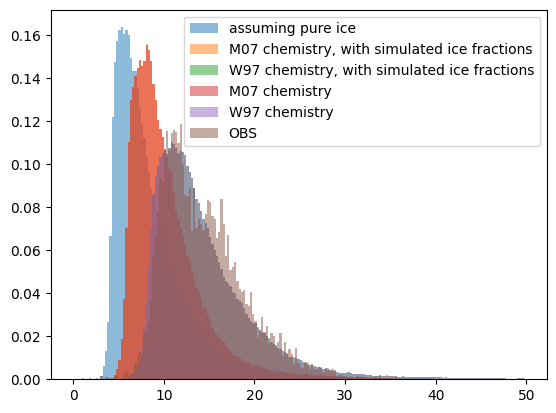

In [32]:
bins = np.arange(0, 50, 0.25)
plt.hist(attenu_pure.flatten(), bins = bins, density = True, alpha = 0.5, label = 'assuming pure ice');
plt.hist(attenu_chemistry_samples_M07.flatten(), bins = bins, density = True, alpha = 0.5, label = 'M07 chemistry, with simulated ice fractions');
plt.hist(attenu_chemistry_samples_W97.flatten(), bins = bins, density = True, alpha = 0.5, label = 'W97 chemistry, with simulated ice fractions');
plt.hist(attenu_chemistry_M07.flatten(), bins = bins, density = True, alpha = 0.5, label = 'M07 chemistry');
plt.hist(attenu_chemistry_W97.flatten(), bins = bins, density = True, alpha = 0.5, label = 'W97 chemistry');
plt.hist(attenu_obs[radar_mask].flatten(), bins = bins, density = True, alpha = 0.5, label = 'OBS')
plt.legend()

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_3746/3501812326.py:1: RuntimeWarning: All-NaN slice encountered
  pixel_min_attenu_chemistry_samples = np.nanmin(attenu_chemistry_samples_W97, axis = 2)
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_3746/3501812326.py:3: RuntimeWarning: All-NaN slice encountered
  pixel_max_attenu_chemistry_samples = np.nanmax(attenu_chemistry_samples_W97, axis = 2)


Text(0.5, 0.98, 'using W97 with $\\beta = 2.2$')

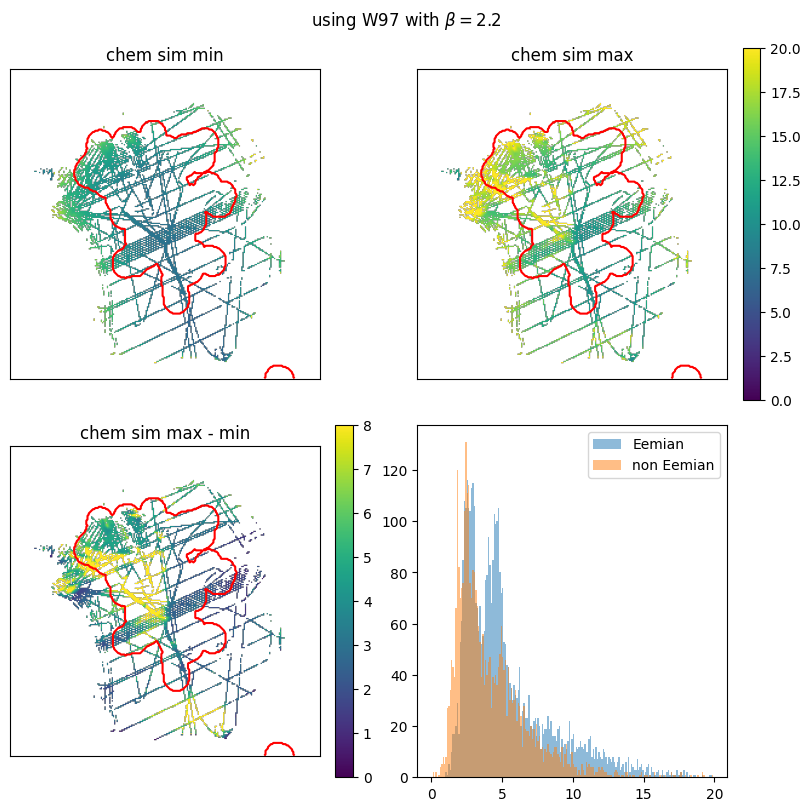

In [6]:
pixel_min_attenu_chemistry_samples = np.nanmin(attenu_chemistry_samples_W97, axis = 2)
pixel_min_attenu_chemistry_samples[~radar_mask] = np.nan
pixel_max_attenu_chemistry_samples = np.nanmax(attenu_chemistry_samples_W97, axis = 2)
pixel_max_attenu_chemistry_samples[~radar_mask] = np.nan

fig, ax = plt.subplots(2, 2, figsize = (8, 8), layout = 'constrained')

vmin = 0
vmax = 20

ax[0, 0].imshow(pixel_min_attenu_chemistry_samples, vmin = vmin, vmax = vmax)
ax[0, 0].contour(LGP_valid_mask, colors = 'red')
ax[0, 0].set_title("chem sim min")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])
ax[0, 0].invert_yaxis()

cb01 = ax[0, 1].imshow(pixel_max_attenu_chemistry_samples, vmin = vmin, vmax = vmax)
ax[0, 1].contour(LGP_valid_mask, colors = 'red')
ax[0, 1].set_title("chem sim max")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])
ax[0, 1].invert_yaxis()
plt.colorbar(cb01)

vmin = 0
vmax = 8

cb10 = ax[1, 0].imshow(pixel_max_attenu_chemistry_samples - pixel_min_attenu_chemistry_samples, vmin = vmin, vmax = vmax)
ax[1, 0].contour(LGP_valid_mask, colors = 'red')
ax[1, 0].set_title("chem sim max - min")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks([])
ax[1, 0].invert_yaxis()
plt.colorbar(cb10)

bins = np.arange(0, 20, 0.1)
ax[1, 1].hist((pixel_max_attenu_chemistry_samples - pixel_min_attenu_chemistry_samples)[LGP_valid_mask].flatten(), bins = bins, alpha = 0.5, label = 'Eemian');
ax[1, 1].hist((pixel_max_attenu_chemistry_samples - pixel_min_attenu_chemistry_samples)[~LGP_valid_mask].flatten(), bins = bins, alpha = 0.5, label = 'non Eemian');
ax[1, 1].legend()

fig.suptitle(rf"using W97 with $\beta = {beta}$")

Text(0.5, 0.98, 'using W97 with $\\beta = 2.2$')

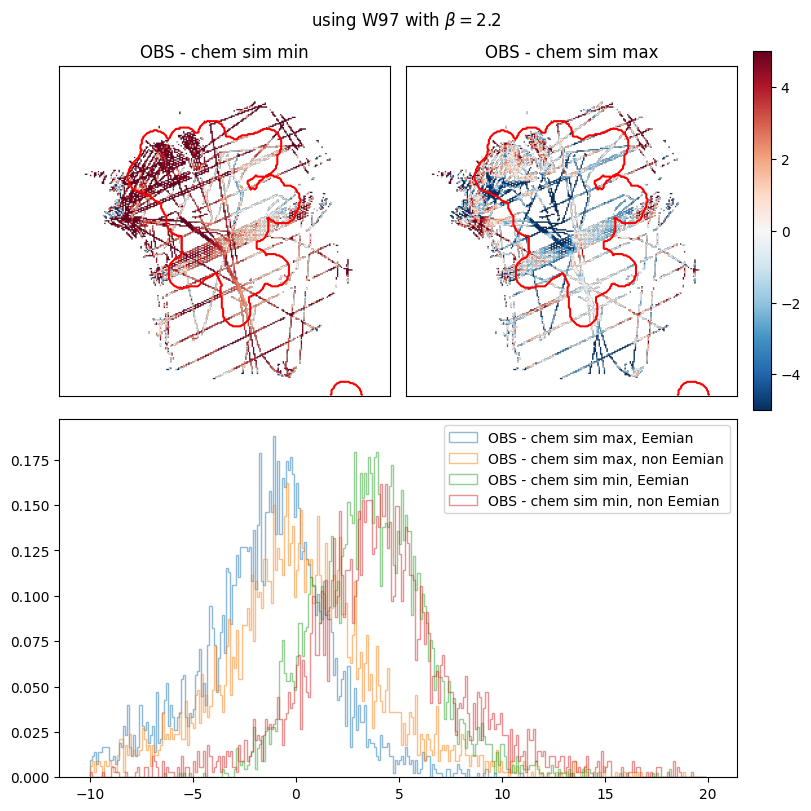

In [7]:
fig, ax = plt.subplot_mosaic([['A', 'B'], ['C', 'C']], figsize = (8, 8), layout = 'constrained')

vmin = -5
vmax = 5

ax['A'].imshow(attenu_obs - pixel_min_attenu_chemistry_samples, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['A'].contour(LGP_valid_mask, colors = 'red')
ax['A'].set_title("OBS - chem sim min")
ax['A'].set_xticks([])
ax['A'].set_yticks([])
ax['A'].invert_yaxis()

cb1 = ax['B'].imshow(attenu_obs - pixel_max_attenu_chemistry_samples, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['B'].contour(LGP_valid_mask, colors = 'red')
ax['B'].set_title("OBS - chem sim max")
ax['B'].set_xticks([])
ax['B'].set_yticks([])
ax['B'].invert_yaxis()
plt.colorbar(cb1)

bins = np.arange(-10, 20, 0.1)
ax['C'].hist((attenu_obs - pixel_max_attenu_chemistry_samples)[LGP_valid_mask].flatten(), density = True, bins = bins, alpha = 0.5, histtype='step', label = 'OBS - chem sim max, Eemian')
ax['C'].hist((attenu_obs - pixel_max_attenu_chemistry_samples)[~LGP_valid_mask].flatten(), density = True, bins = bins, alpha = 0.5,  histtype='step', label = 'OBS - chem sim max, non Eemian')
ax['C'].hist((attenu_obs - pixel_min_attenu_chemistry_samples)[LGP_valid_mask].flatten(), density = True, bins = bins, alpha = 0.5, histtype='step', label = 'OBS - chem sim min, Eemian')
ax['C'].hist((attenu_obs - pixel_min_attenu_chemistry_samples)[~LGP_valid_mask].flatten(), density = True, bins = bins, alpha = 0.5, histtype='step', label = 'OBS - chem sim min, non Eemian')
ax['C'].legend()

fig.suptitle(rf"using W97 with $\beta = {beta}$")

In [42]:
Tm_W97 = np.full((256, 256), np.nan)

Tm_W97[radar_mask] = ice.atten_rate_to_temperature_mix_GrISfraction(attenu_obs[radar_mask],
                                  kind = "W97",
                                  beta = 2.2,
                                  Hol_f = Hol_f[radar_mask].flatten(),
                                  LGP_f = LGP_f[radar_mask].flatten())

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_3746/2068227658.py:10: RuntimeWarning: Mean of empty slice
  Tm_ensemble_mean = np.nanmean(Tm, axis = 2)


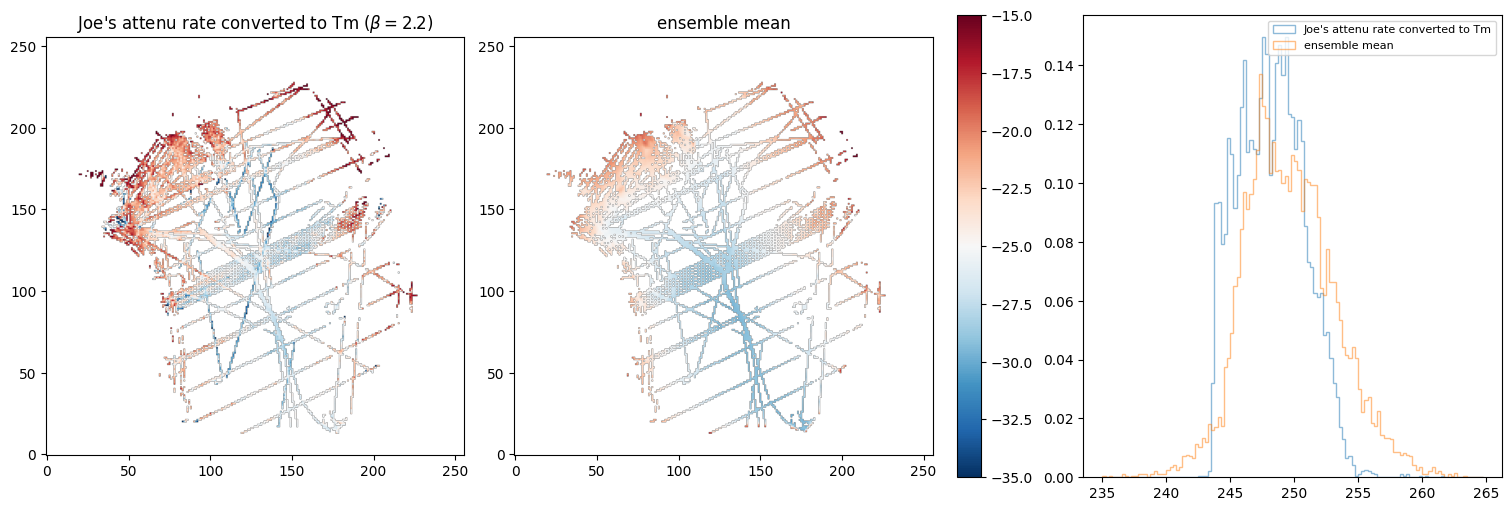

In [43]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5), layout = 'constrained')

vmin = -35
vmax = -15

ax[0].imshow(Tm_W97 - 273.15, vmin = vmin, vmax = vmax, cmap = "RdBu_r")
ax[0].invert_yaxis()
ax[0].set_title(r"Joe's attenu rate converted to Tm ($\beta = 2.2$)")

Tm_ensemble_mean = np.nanmean(Tm, axis = 2)
Tm_ensemble_mean[~radar_mask] = np.nan

im1 = ax[1].imshow(Tm_ensemble_mean - 273.15, vmin = vmin, vmax = vmax, cmap = "RdBu_r")
ax[1].invert_yaxis()
ax[1].set_title("ensemble mean")
plt.colorbar(im1)

bins = np.arange(235, 265, 0.25)

ax[2].hist(Tm_ensemble_mean.flatten(), bins = bins, density = True, alpha = 0.5, histtype='step', label = rf"Joe's attenu rate converted to Tm");
ax[2].hist(Tm_W97.flatten(), bins = bins, density = True, alpha = 0.5, histtype='step', label = rf"ensemble mean");
ax[2].legend(fontsize = 8)

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_3746/1557969883.py:10: RuntimeWarning: Mean of empty slice
  Tm_ensemble_mean = np.nanmean(Tm, axis = 2)


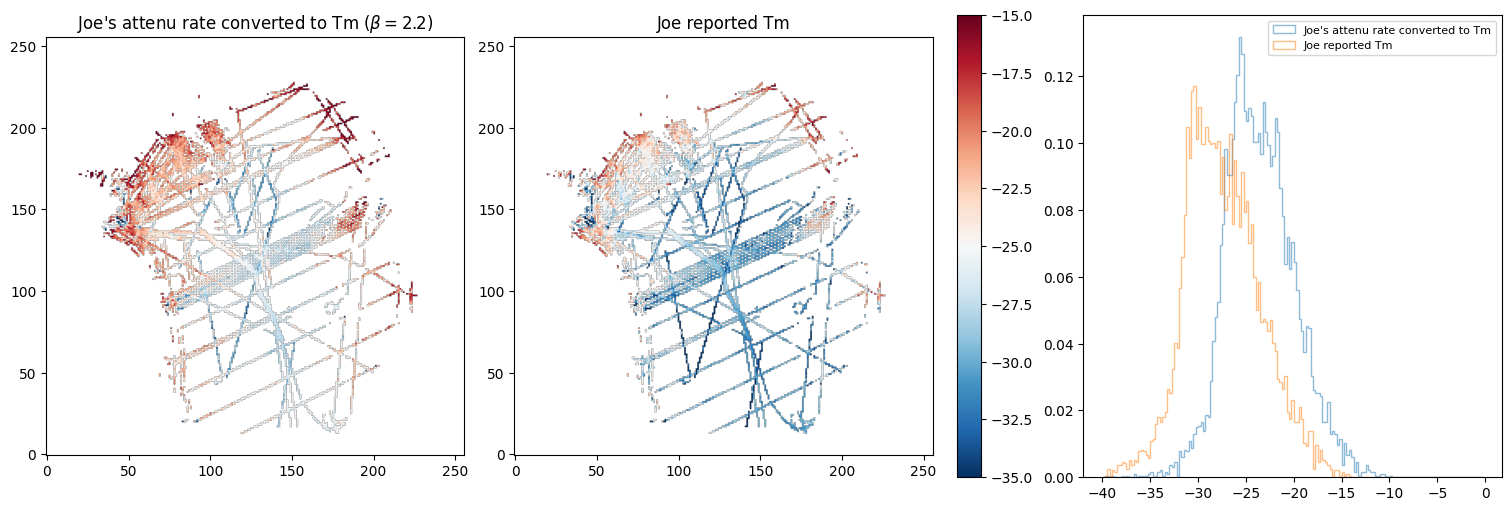

In [44]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5), layout = 'constrained')

vmin = -35
vmax = -15

ax[0].imshow(Tm_W97 - 273.15, vmin = vmin, vmax = vmax, cmap = "RdBu_r")
ax[0].invert_yaxis()
ax[0].set_title(rf"Joe's attenu rate converted to Tm ($\beta = {beta}$)")

Tm_ensemble_mean = np.nanmean(Tm, axis = 2)
Tm_ensemble_mean[~radar_mask] = np.nan

im1 = ax[1].imshow(radar_Tm, vmin = vmin, vmax = vmax, cmap = "RdBu_r")
ax[1].invert_yaxis()
ax[1].set_title("Joe reported Tm")
plt.colorbar(im1)

bins = np.arange(-40, 0, 0.25)

ax[2].hist((Tm_W97 - 273.15).flatten(), bins = bins, density = True, alpha = 0.5, histtype='step', label = rf"Joe's attenu rate converted to Tm");
ax[2].hist(radar_Tm[radar_mask].flatten(), bins = bins, density = True, alpha = 0.5, histtype='step', label = rf"Joe reported Tm");
ax[2].legend(fontsize = 8)